In [34]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
%matplotlib inline

In [35]:
df = pd.read_csv("Algerian_forest_fires_dataset_cleaned_data.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.0,3.0,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.0,64.0,4.0,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.0,47.0,2.0,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.0,28.0,1.0,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.0,3.0,14.2,1.2,3.9,0.5,not fire,0


In [36]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [37]:
df.drop(['day','month','year'],axis=1, inplace=True)

In [38]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.0,3.0,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.0,64.0,4.0,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.0,47.0,2.0,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.0,28.0,1.0,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.0,3.0,14.2,1.2,3.9,0.5,not fire,0


In [39]:
# converting strings into numerics 
df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [40]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.0,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.0,41.0,6.0,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.0,45.0,3.0,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.0,79.0,4.0,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.0,67.0,3.0,16.5,1.2,4.8,0.5,0,1


In [41]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [68]:
x = df.drop('FWI', axis=1)
y = df['FWI']

In [69]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.0,3.0,7.6,1.3,3.4,0,0
1,29,61,13,1.0,64.0,4.0,7.6,1.0,3.9,0,0
2,26,82,22,13.0,47.0,2.0,7.1,0.3,2.7,0,0
3,25,89,13,2.0,28.0,1.0,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.0,3.0,14.2,1.2,3.9,0,0


In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [71]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((194, 11), (49, 11), (194,), (49,))

In [72]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.303287,0.690989,0.469269,0.372163,0.613138,0.446280,0.539642,0.258344
RH,-0.653725,1.000000,0.211645,0.229360,-0.649143,-0.402809,-0.220945,-0.714640,-0.346511,-0.454926,-0.408441
Ws,-0.308149,0.211645,1.000000,0.239660,-0.174849,0.006064,0.092866,-0.002300,0.037465,-0.075322,-0.202357
Rain,-0.303287,0.229360,0.239660,1.000000,-0.501458,-0.251332,-0.271450,-0.305796,-0.264086,-0.326093,-0.044850
FFMC,0.690989,-0.649143,-0.174849,-0.501458,1.000000,0.611753,0.519211,0.752326,0.597861,0.785554,0.255546
DMC,0.469269,-0.402809,0.006064,-0.251332,0.611753,1.000000,0.875670,0.679810,0.983723,0.605903,0.187319
DC,0.372163,-0.220945,0.092866,-0.271450,0.519211,0.875670,1.000000,0.512934,0.946181,0.538893,-0.083038
ISI,0.613138,-0.714640,-0.002300,-0.305796,0.752326,0.679810,0.512934,1.000000,0.637669,0.740072,0.291889
BUI,0.446280,-0.346511,0.037465,-0.264086,0.597861,0.983723,0.946181,0.637669,1.000000,0.602102,0.090326
Classes,0.539642,-0.454926,-0.075322,-0.326093,0.785554,0.605903,0.538893,0.740072,0.602102,1.000000,0.196276


<Axes: >

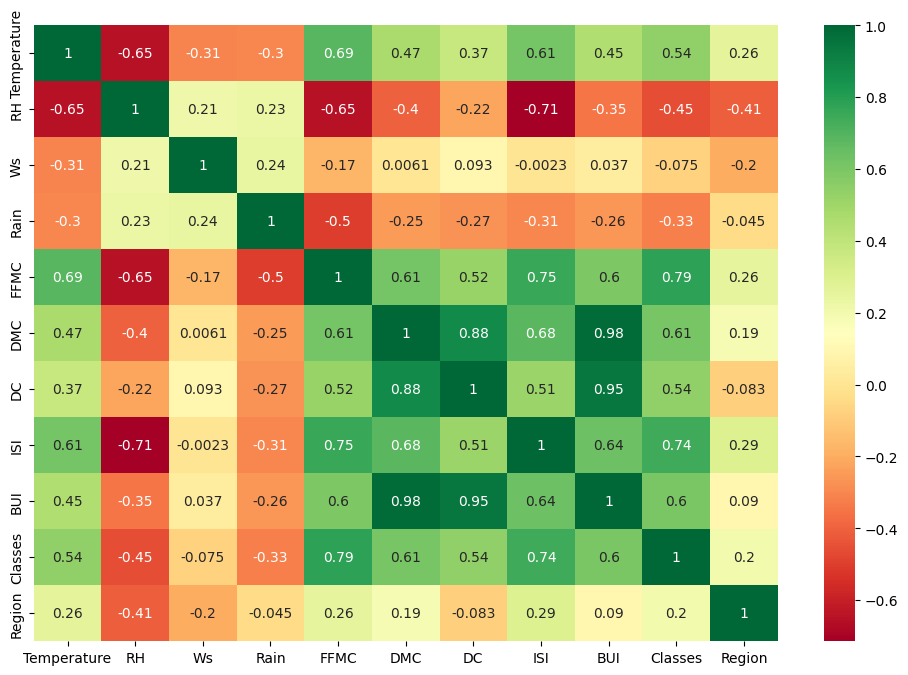

In [73]:
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(),annot=True, cmap='RdYlGn')

### Multi-Colinearity
* independent features that are highly corelated then it basically raises the concern of multi-colinearity

In [74]:
def correlation(dataset, thresold):
    corr_col = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):#columns
        for j in range(i):#rows
            if abs(corr_matrix.iloc[i,j] > thresold): #if value if greater than thresold
                colname = corr_matrix.columns[i] # get that column
                corr_col.add(colname) # add that column to set
    return corr_col #return that set
corr_features = correlation(X_train, 0.85)
corr_features

{'BUI', 'DC'}

In [75]:
# dropping correlation features , because it appears multiple times
X_train.drop(corr_features,axis=1, inplace=True)
X_test.drop(corr_features,axis=1, inplace=True)
X_train.shape, X_test.shape

((194, 9), (49, 9))

## Feature Scaling or Standadization

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boxplots to Understand Effect of Standard Scaler

Text(0.5, 1.0, 'X_train After Scaling')

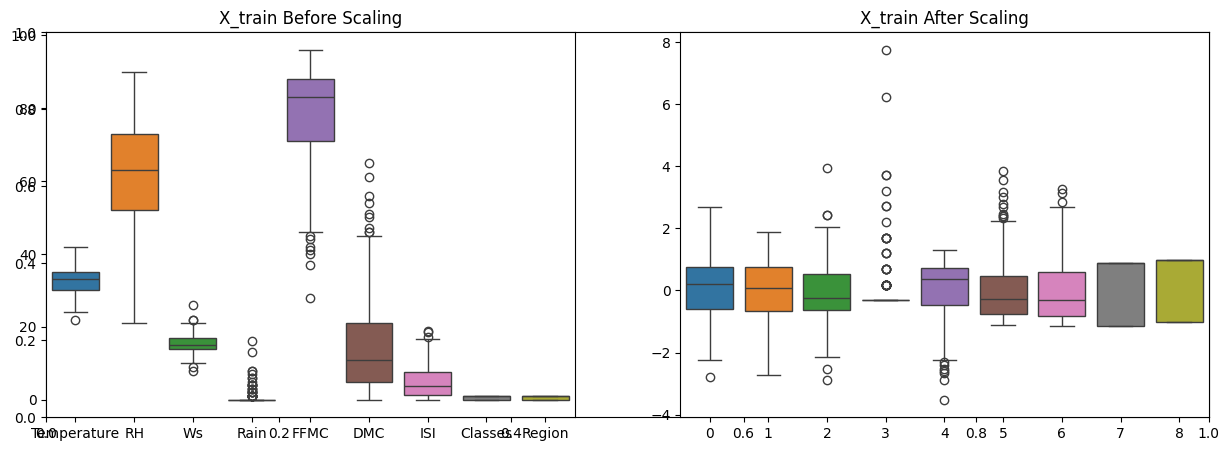

In [77]:
plt.subplots(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train After Scaling")

## Linear Regression Model

Mean Absolute Error : 0.5071978879498297
Mean Squared Error : 0.599596575397794
Root Mean Square Error : 0.7743362159926358
R2 Score : 0.9802168326194439


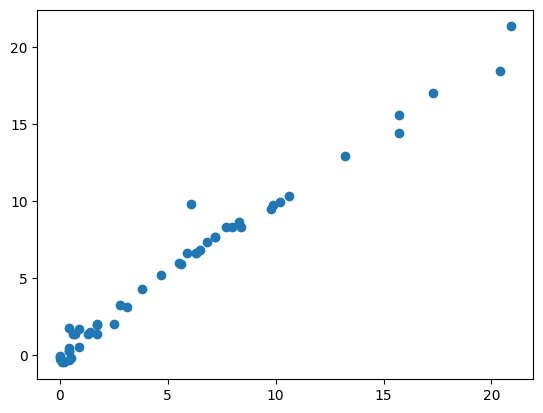

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
linreg = LinearRegression()

# train the model
linreg.fit(X_train_scaled, y_train)

# predict using model
y_pred = linreg.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

## Lasso

Mean Absolute Error : 1.0215072958077314
Mean Squared Error : 1.7688172167543283
Root Mean Square Error : 1.3299688781149461
R2 Score : 0.9416394147324062


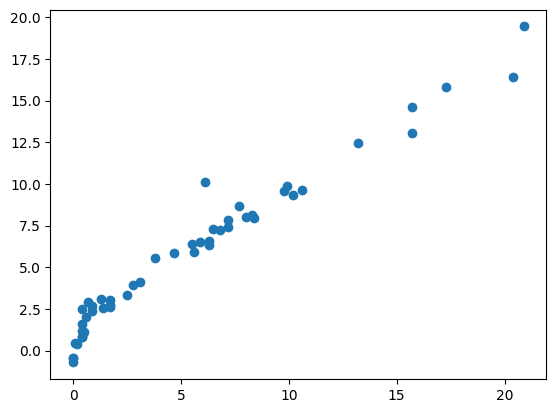

In [79]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
lasso = Lasso()

# train the model
lasso.fit(X_train_scaled, y_train)

# predict using model
y_pred = lasso.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

## LassoCV

Mean Absolute Error : 0.5693001588053689
Mean Squared Error : 0.7015241729017024
Root Mean Square Error : 0.8375703987735612
R2 Score : 0.976853820212677


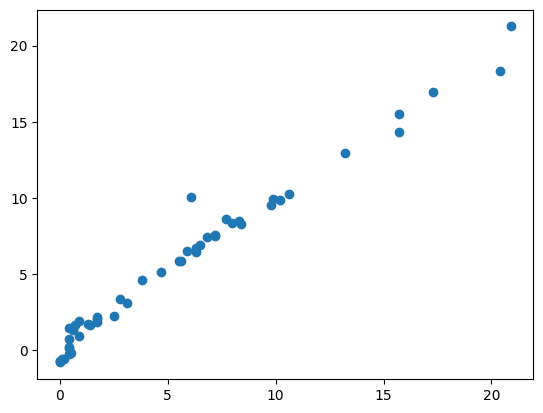

In [85]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
lassoCV = LassoCV(cv=5)

# train the model
lassoCV.fit(X_train_scaled, y_train)

# predict using model
y_pred = lassoCV.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

## Ridge

Mean Absolute Error : 0.5269360252091664
Mean Squared Error : 0.6155187785136687
Root Mean Square Error : 0.7845500484441185
R2 Score : 0.9796914933793064


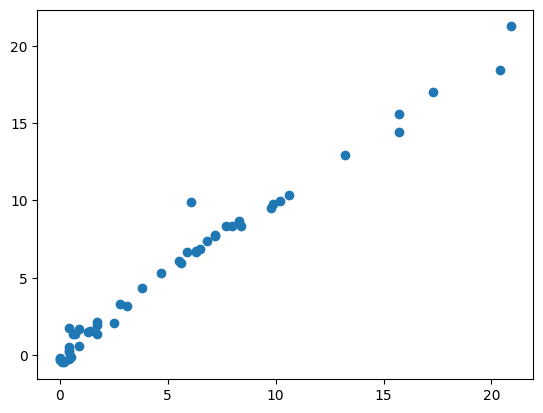

In [81]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
ridge = Ridge()

# train the model
ridge.fit(X_train_scaled, y_train)

# predict using model
y_pred = ridge.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

Mean Absolute Error : 0.6893652443617703
Mean Squared Error : 0.862409764703607
Root Mean Square Error : 0.9286601987291191
R2 Score : 0.9715455400751106


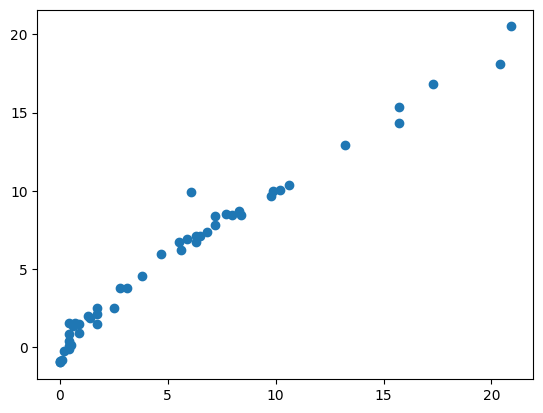

In [86]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
ridgeCV = RidgeCV(cv=5)

# train the model
ridgeCV.fit(X_train_scaled, y_train)

# predict using model
y_pred = ridgeCV.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

Mean Absolute Error : 1.6952307877897623
Mean Squared Error : 4.043620944811093
Root Mean Square Error : 2.0108756661740905
R2 Score : 0.8665842447121247


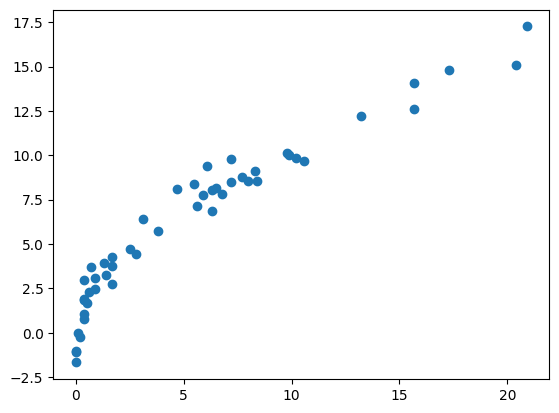

In [87]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
elasticnet = ElasticNet()

# train the model
elasticnet.fit(X_train_scaled, y_train)

# predict using model
y_pred = elasticnet.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

Mean Absolute Error : 0.5751432046276203
Mean Squared Error : 0.6789440605317978
Root Mean Square Error : 0.8239806190268056
R2 Score : 0.9775988313765402


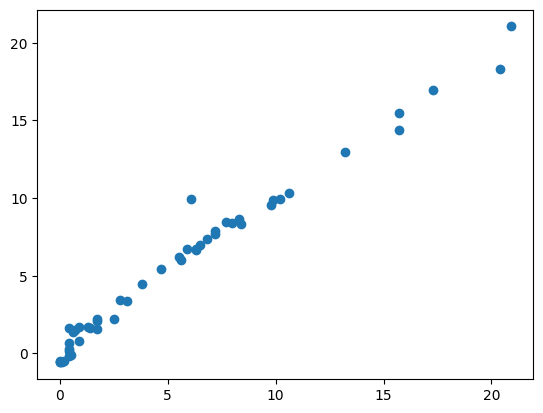

In [88]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# select model
elasticCV = ElasticNetCV(cv=5)

# train the model
elasticCV.fit(X_train_scaled, y_train)

# predict using model
y_pred = elasticCV.predict(X_test_scaled)

# check scores
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R2 Score : {score}")

plt.scatter(y_test, y_pred)

* pickle the machine learning models, preprocessing model StandardScaler

In [ ]:
import pickle as pkl 
pkl.open

In [89]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [90]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [92]:
import pickle as pkl 
pkl.dump(scaler,open('scaler.pkl','wb'))
pkl.dump(ridge, open('ridge.pkl','wb'))